In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import probplot

In [37]:
df = pd.read_csv("data/mlb_stats.csv")

In [38]:
df.head()

,"last_name, first_name",player_id,year,player_age,pa,home_run,k_percent,bb_percent,batting_avg,on_base_plus_slg,...,avg_swing_speed,fast_swing_rate,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,whiff_percent,pull_percent,groundballs_percent
0,"Cabrera, Miguel",408234,2023,40,370,4,20.0,8.4,0.257,0.675,...,68.3,0.7,7.4,34.2,4.2,37.6,98.972071,25.6,35.7,49.8
1,"Peralta, David",444482,2023,35,422,7,17.1,4.7,0.259,0.675,...,72.1,24.5,8.2,31.1,4.9,44.2,100.838135,22.5,38.4,49.1
2,"Blackmon, Charlie",453568,2023,36,413,8,13.3,9.4,0.279,0.803,...,66.9,1.6,18.1,39.0,4.9,31.5,97.605452,19.6,45.5,36.4
3,"Maldonado, Martín",455117,2023,36,407,15,34.2,7.4,0.191,0.606,...,71.8,15.6,18.1,32.8,8.5,40.0,99.511384,34.3,46.0,38.7
4,"Solano, Donovan",456781,2023,35,450,5,22.2,8.9,0.282,0.760,...,68.2,6.3,13.1,43.1,6.1,43.7,100.102936,25.4,34.2,41.0


In [39]:
df.shape

(961, 22)

# Abstract

# Introduction

# Methodology

# Data

### Data Source

The data was sourced from [Baseball Savant](https://baseballsavant.mlb.com/), the official advanced statistics webpage for Major League Baseball. We used their Custom Leaderboard feature to make a custom dataset linked [here](https://baseballsavant.mlb.com/leaderboard/custom?year=2025%2C2024%2C2023&type=batter&filter=&min=250&selections=player_age%2Cpa%2Chome_run%2Ck_percent%2Cbb_percent%2Cbatting_avg%2Con_base_plus_slg%2Cb_gnd_into_dp%2Cwoba%2Cavg_swing_speed%2Cfast_swing_rate%2Claunch_angle_avg%2Csweet_spot_percent%2Cbarrel_batted_rate%2Chard_hit_percent%2Cavg_best_speed%2Cwhiff_percent%2Cpull_percent%2Cgroundballs_percent&chart=false&x=pa&y=pa&r=no&chartType=beeswarm&sort=pa&sortDir=desc). As a group we chose to include 22 total variables (columns). Each observation is a player's batting statistics within a season. We included observations from three different years (the 2023, 2024, and 2025 seasons).

#### Observations and Sample

There are 961 total observations (rows) in the dataset. Out of the total Baseball Savant database, we do not have a completely random sample of the data. However, in order to draw proper conclusions from each observation, we have to put nonrandom filters on the observations to control for as much random noise as possible. The main filters are the seasons we are using (2023-2025), and only players with a minimum of 250 plate appearances in a season are considered. We still include every possible data point matching the criteria we filter for. In totality, we have every MLB player's single season batting statistics from 2023 to 2025 who had at least 250 plate appearances. Since we are not leaving out any observations after filtering the data, we have a census of the population space described above. Our scope of inference is the entire population space since we are not leaving out any observations. For MLB players who have at least 250 plate appearances in a season, it's reasonable to assume that our findings can apply to hitter statistics in the present and near future.

### Missingness and Duplicates

Below, we check for missingness in the dataset by using the `missingno` library to construct a missingness bar plot. We can see that there is no `NaN` values which is a good sign. However we don't know for sure if there are secretly missing values until we perform exploratory data analysis and analyze the distributions of the variables. This makes sense since each observation is a player with plenty of plate appearances which makes each stat trackable.

<Axes: >

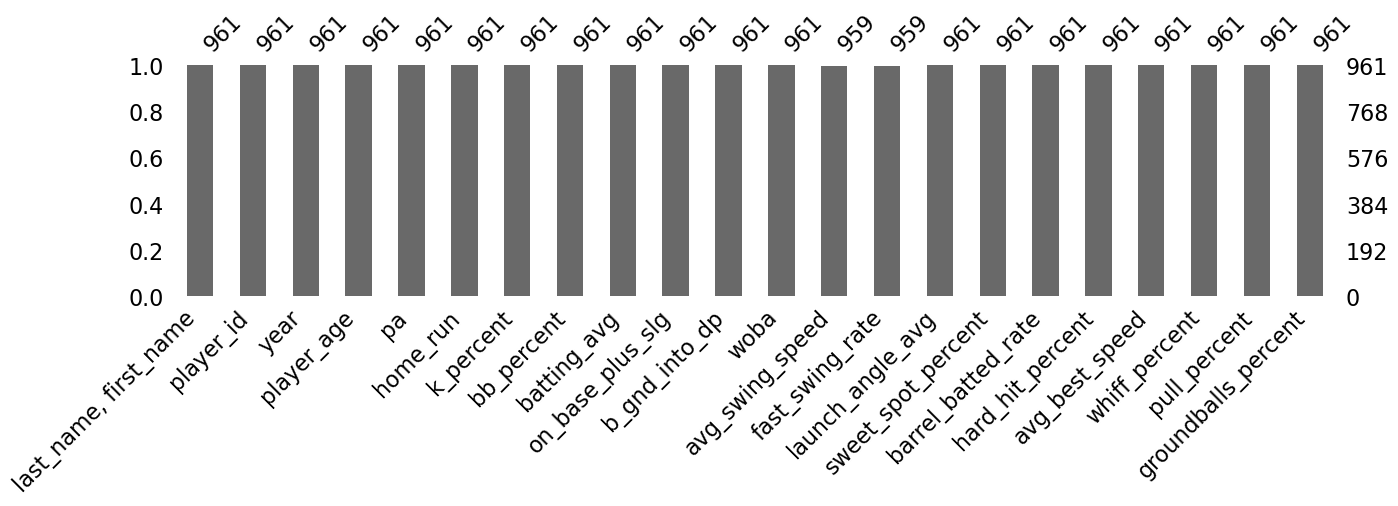

In [40]:
msno.bar(df, figsize = (15, 3))

Additionally, we will check for duplicate values in the dataset.

In [41]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset!

### Restructuring and Relabeling

Now let's check the names of the columns to see if we need to change them. Ideally we only want lowercase letters and underscores that act as spaces.

In [42]:
df.columns

Index(['last_name, first_name', 'player_id', 'year', 'player_age', 'pa',
       'home_run', 'k_percent', 'bb_percent', 'batting_avg',
       'on_base_plus_slg', 'b_gnd_into_dp', 'woba', 'avg_swing_speed',
       'fast_swing_rate', 'launch_angle_avg', 'sweet_spot_percent',
       'barrel_batted_rate', 'hard_hit_percent', 'avg_best_speed',
       'whiff_percent', 'pull_percent', 'groundballs_percent'],
      dtype='object')

Most of the column names appear to be tidied up which is great! The only column names that we should change are `last_name, first_name` and `on_base_plus_slg`. `last_name, first_name` contains a space and comma which we do not want. We will rename the column to `player_name`. `on_base_plus_slg` is an okay column name, but as the outcome variable it will be called constantly and the name is a tad long. Since we already know this variable under a different and much shorter name (OPS), we will convert the column name to `ops`.

In [45]:
df = df.rename(columns = {"last_name, first_name": "player_name",
                          "on_base_plus_slg": "ops"})
df.columns

Index(['player_name', 'player_id', 'year', 'player_age', 'pa', 'home_run',
       'k_percent', 'bb_percent', 'batting_avg', 'ops', 'b_gnd_into_dp',
       'woba', 'avg_swing_speed', 'fast_swing_rate', 'launch_angle_avg',
       'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent',
       'avg_best_speed', 'whiff_percent', 'pull_percent',
       'groundballs_percent'],
      dtype='object')

Next we will take a look at the data type of each column to verify that each variable is the correct data type.

### Type Correction / Reformatting

In [46]:
df.dtypes

player_name             object
player_id                int64
year                     int64
player_age               int64
pa                       int64
home_run                 int64
k_percent              float64
bb_percent             float64
batting_avg            float64
ops                    float64
b_gnd_into_dp            int64
woba                   float64
avg_swing_speed        float64
fast_swing_rate        float64
launch_angle_avg       float64
sweet_spot_percent     float64
barrel_batted_rate     float64
hard_hit_percent       float64
avg_best_speed         float64
whiff_percent          float64
pull_percent           float64
groundballs_percent    float64
dtype: object

It turns out that all the non-identifier variables we selected are in fact numeric data types, and we don't need to change any of them. Technically `player_id` as an integer does not hold any numeric value but it is an identifier and can be mostly left out of our analysis and any of our models.

As for reformatting, we could standardize the `player_name` values, but for the purposes of this project it is unnecessary since `player_id` already accurately differentiates players, and `player_name` will not be a part of our models.

### Exploratory Data Analysis and Visualizations

We will now start performing EDA to be more informed about our variables and their relationships to each other and the outcome variable `ops`. First I want to isolate a list of variables that we are interested in exploring.

# Results

# Conclusion

# References